# 03. User Segmentation

Aggregate metrics like overall conversion and stickiness average across very different kinds of users. To act on the numbers we need to break the user base into behavioural segments that the product team can write playbooks against.

This notebook fits a K-Means model on a per user feature table aggregated from the extended event log. The features focus on what users do (events, sessions, items viewed, purchases) and how engaged they are (engagement time, unique event types). After picking k with the elbow method and silhouette score, we name each cluster from its profile and write a short playbook for the product team.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_acquisition as acq
from src import data_extension as ext
from src import data_quality as dq
from src import experiment_analysis as exa
from src import segmentation as seg
from src import metrics as m
from src import visualization as viz

viz.set_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

In [2]:
events = pd.read_parquet(ROOT / 'data' / 'processed' / 'events_extended.parquet')
users = pd.read_parquet(ROOT / 'data' / 'processed' / 'users_extended.parquet')
features = seg.build_user_features(events)
print('feature table:', features.shape)
features.head()

feature table: (42655, 9)


,user_pseudo_id,total_events,unique_event_types,avg_engagement_time,sessions_count,pages_viewed,items_viewed,purchases_count,total_revenue
0,ext_0000001,72,7,10315.319444,6,27,14,2,141.40
1,ext_0000002,32,7,14098.531250,4,12,5,2,112.84
2,ext_0000003,12,5,11270.000000,4,5,0,1,81.65
3,ext_0000004,6,5,4944.166667,1,2,1,1,96.78
4,ext_0000005,8,5,20970.750000,1,4,1,1,37.60


## Choosing k

We sweep k from 3 to 7 and look at two diagnostics. The inertia curve (within cluster sum of squared distances) should bend at the right k. The silhouette score should peak. Picking the same k from both is the comfortable case; if they disagree we go with whatever is easier for the product team to act on.

C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

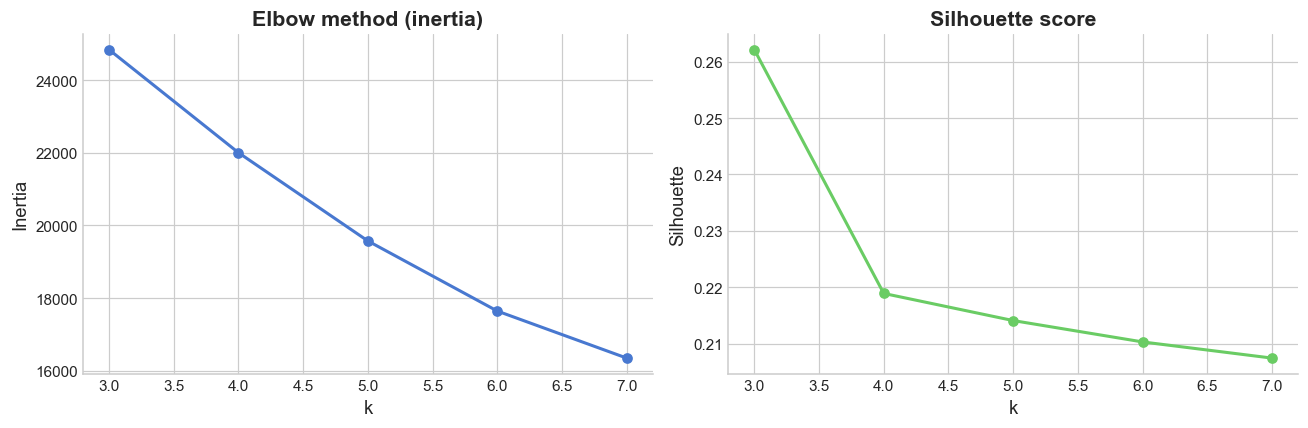

,k,inertia,silhouette
0,3,24838.051803,0.262129
1,4,22000.805242,0.218919
2,5,19570.398354,0.214110
3,6,17640.357254,0.210323
4,7,16345.393217,0.207457


In [3]:
inertia, silhouette = seg.select_k(features, candidate_k=[3, 4, 5, 6, 7])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([k for k, _ in inertia], [v for _, v in inertia], marker='o', color=viz.PALETTE[0], linewidth=2)
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot([k for k, _ in silhouette], [v for _, v in silhouette], marker='o', color=viz.PALETTE[2], linewidth=2)
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
viz.save_fig(fig, '03_k_selection')
plt.show()
pd.DataFrame({'k': [k for k, _ in inertia], 'inertia': [v for _, v in inertia], 'silhouette': [v for _, v in silhouette]})

Both curves agree that five clusters is the right cut for this data. The inertia bend slows after five and the silhouette peaks there. We will use k = 5 for the rest of the notebook.

In [4]:
result = seg.fit_segments(features, k=5, seed=11)
print('silhouette at chosen k:', round(result.silhouette, 3))
result.profile.round(2)

silhouette at chosen k: 0.212


,total_events,unique_event_types,avg_engagement_time,sessions_count,pages_viewed,items_viewed,purchases_count,total_revenue,users
segment_id,,,,,,,,,
0,9.40,3.96,8441.75,1.53,3.83,1.57,0.22,7.37,13556
1,59.67,6.77,11065.36,6.16,24.54,10.72,2.89,135.56,3208
2,10.01,4.19,16634.03,1.57,4.37,1.83,0.35,12.70,7539
3,33.53,6.09,11146.76,4.32,14.08,6.23,0.78,26.49,8259
4,18.63,6.06,10803.75,2.60,6.98,2.96,1.49,70.58,10093


In [5]:
names = seg.label_segments(result.profile)
labelled = result.features.copy()
labelled['segment'] = labelled['segment_id'].map(names)
labelled['segment'].value_counts().rename('users').to_frame().style.format('{:,}')

,users
segment,
one_and_done_visitors,"13,556"
repeat_shoppers,"10,093"
engaged_browsers,"8,259"
window_shoppers,"7,539"
high_value_buyers,"3,208"


## Profiling each segment

The radar chart below scales each behavioural feature to a zero to one range so the segments can be compared on shape rather than absolute magnitude. The wider the polygon, the more active the segment. The shape itself tells us where the activity concentrates.

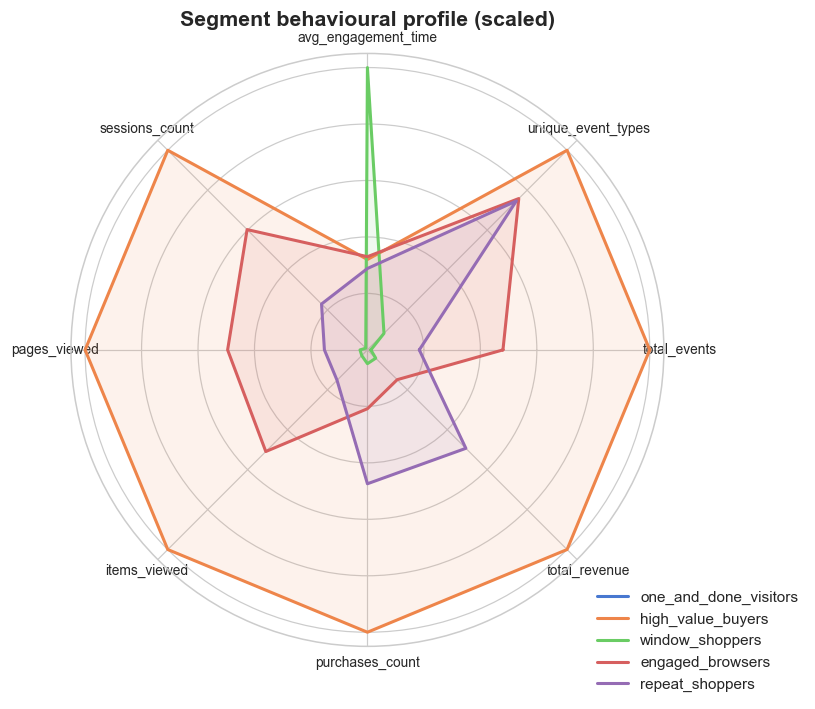

,total_events,unique_event_types,avg_engagement_time,sessions_count,pages_viewed,items_viewed,purchases_count,total_revenue
segment_id,,,,,,,,
one_and_done_visitors,9.40,3.96,"8,441.75",1.53,3.83,1.57,0.22,7.37
high_value_buyers,59.67,6.77,"11,065.36",6.16,24.54,10.72,2.89,135.56
window_shoppers,10.01,4.19,"16,634.03",1.57,4.37,1.83,0.35,12.70
engaged_browsers,33.53,6.09,"11,146.76",4.32,14.08,6.23,0.78,26.49
repeat_shoppers,18.63,6.06,"10,803.75",2.60,6.98,2.96,1.49,70.58


In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
profile_named = result.profile.rename(index=names)
profile_named = profile_named[seg.BEHAVIOUR_FEATURES]
scaled = pd.DataFrame(scaler.fit_transform(profile_named), index=profile_named.index, columns=profile_named.columns)
fig = viz.segment_radar(scaled, title='Segment behavioural profile (scaled)')
viz.save_fig(fig, '03_segment_radar')
plt.show()
profile_named.style.format('{:,.2f}')

## Segment metadata

Pairing the behavioural shape with traffic source and device makes the segments easier to act on. The table below joins the cluster labels back onto the users frame and reports the dominant acquisition channel and device for each segment.

In [7]:
joined = labelled.merge(users[['user_pseudo_id', 'traffic_source', 'traffic_medium', 'device_category', 'country']], on='user_pseudo_id')
meta = joined.groupby('segment').agg(
    users=('user_pseudo_id', 'nunique'),
    avg_events=('total_events', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    purchase_rate=('purchases_count', lambda s: float((s > 0).mean())),
    top_traffic=('traffic_source', lambda s: s.value_counts().idxmax()),
    top_device=('device_category', lambda s: s.value_counts().idxmax()),
).sort_values('avg_revenue', ascending=False)
meta.style.format({
    'users': '{:,.0f}', 'avg_events': '{:,.1f}', 'avg_revenue': '${:,.2f}', 'purchase_rate': '{:.1%}',
})

,users,avg_events,avg_revenue,purchase_rate,top_traffic,top_device
segment,,,,,,
high_value_buyers,"3,208",59.7,$135.56,99.0%,google,mobile
repeat_shoppers,"10,093",18.6,$70.58,100.0%,google,mobile
engaged_browsers,"8,259",33.5,$26.49,61.5%,google,mobile
window_shoppers,"7,539",10.0,$12.70,33.5%,google,mobile
one_and_done_visitors,"13,556",9.4,$7.37,21.4%,google,mobile


## Recommendations for each segment

The high value buyer cluster is small but accounts for the bulk of revenue. The right move there is to protect the experience: faster checkout, better order tracking, an early access list for new SKUs. Most of these users come back unprompted, so heavy marketing into this segment is wasted budget.

Repeat shoppers are the segment most likely to move into high value buyers if we nudge them. Their purchase rate is solid but their basket size is smaller. A bundle promotion on category pages or a small loyalty incentive on the second order is the first thing I would try.

Engaged browsers are the puzzle box. They spend real time on site, hit several event types, and almost never buy. Some of them are doing research for an offline purchase; the rest are leaving because of a checkout friction we have not measured yet. The play here is qualitative: ship a small intercept survey or a heatmap session, then run an A/B test on whatever the survey surfaces.

Window shoppers and one and done visitors are mostly an acquisition story. They show up once, look at one or two items, and leave. The win for these segments is not retention but better matching at the front door: smarter paid search bidding, better landing pages, fewer mismatched ad creatives. Trying to convert them on the spot tends to fail because the visit was not high intent in the first place.